# Imports

In [1]:
# Automatically reloads modules before each cell execution, so code changes in library are always propogated.
#reload or load? _ext
%load_ext autoreload
%autoreload 2

%load_ext snakeviz

import networkx as nx
from networkx import MultiDiGraph
import osmnx as ox
import numpy as np
import pandas as pd
from difflib import SequenceMatcher
import concurrent.futures
import copy

from PreProcessing import graph_preprocessing
import graph_manager
import investigation
import plotting
import constants

ox.settings.useful_tags_way = [
    "bridge", "tunnel", "oneway", "lanes", "highway",
     "width", "name", "name:en", "bicycle", "cycleway"]

SEED = 72
SAMPLE_K = 1000

# Network setup

In [2]:
#NOTE the length attribute is given in meters
#You project not to fix lengths, but to make sure your geometry math (like areas or spatial intersections) makes sense in linear units.
#Simplify is used to significantly reduce the number of nodes, removing dead ends and combining nodes with no intersections
LOCATION = "Malta (island)"

G_master = graph_preprocessing.load_network(LOCATION)
G_master, gdf_localities_proj = graph_preprocessing.clean_graph(G_master)

Loading OSM networks for Malta (island)...
creating master graph network...
Adding elevation data.....
Imputing missing elevation values
Iteration 1: imputed 392 nodes
Iteration 2: imputed 90 nodes
Iteration 3: imputed 20 nodes
Iteration 4: imputed 6 nodes
Iteration 5: imputed 0 nodes
node elevation nan <class 'float'>
NOde246587560 elevation is problematic :/
NOde5243805554 elevation is problematic :/
NOde9068823240 elevation is problematic :/
node elevation 59.0 <class 'float'>
Number of localities: 54


## Road type classification

In [3]:
graph_manager.summarise_road_type_stats(G_master)

Highway type counts:
residential: 39042
service: 15822
track: 11099
tertiary: 6151
secondary: 5330
non_motorised: 2731
trunk: 2122
primary: 1985
cycleway: 305
-------
bikeway classification type counts:
None: 82021
yes: 2191
designated: 309
no: 45
permissive: 14
permit: 4
private: 3
------
cycleway type counts:
None: 84299
no: 201
shared: 30
track: 21
shared_lane: 14
lane: 14
crossing: 8


In [4]:
print("Nodes:", G_master.number_of_nodes())
print("Edges (total, counts parallel edges separately):", G_master.number_of_edges())
print(G_master.graph)

Nodes: 35755
Edges (total, counts parallel edges separately): 84587
{'created_date': '2025-11-15 15:26:55', 'created_with': 'OSMnx 2.0.5', 'crs': <Projected CRS: EPSG:32633>
Name: WGS 84 / UTM zone 33N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 12°E and 18°E, northern hemisphere between equator and 84°N, onshore and offshore. Austria. Bosnia and Herzegovina. Cameroon. Central African Republic. Chad. Congo. Croatia. Czechia. Democratic Republic of the Congo (Zaire). Gabon. Germany. Hungary. Italy. Libya. Malta. Niger. Nigeria. Norway. Poland. San Marino. Slovakia. Slovenia. Svalbard. Sweden. Vatican City State.
- bounds: (12.0, 0.0, 18.0, 84.0)
Coordinate Operation:
- name: UTM zone 33N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich
, 'simplified': True}


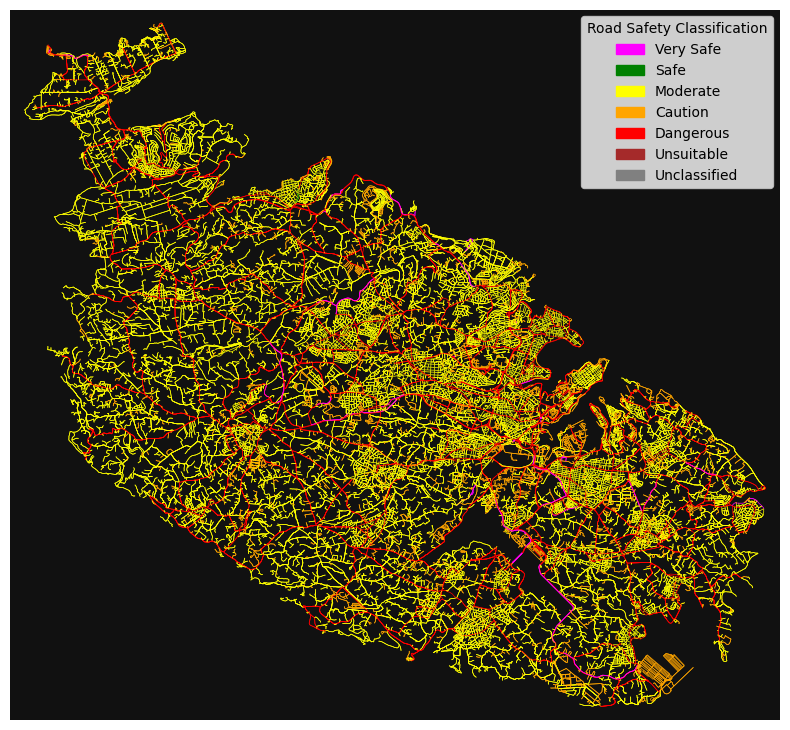

In [5]:
plotting.plot_road_classification(G_master)

In [6]:
"""investigation.analyze_parallel_edges(my_graph.G_master)
investigation.compare_parallel_edges(my_graph.G_master)
investigation.plot_parallel_edges(my_graph.G_master)
print("-----")"""

'investigation.analyze_parallel_edges(my_graph.G_master)\ninvestigation.compare_parallel_edges(my_graph.G_master)\ninvestigation.plot_parallel_edges(my_graph.G_master)\nprint("-----")'

## Topology

Fetched elevations for 35755 / 35755 nodes


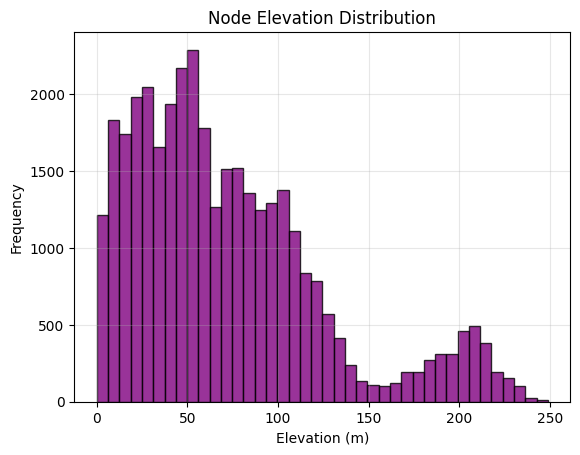

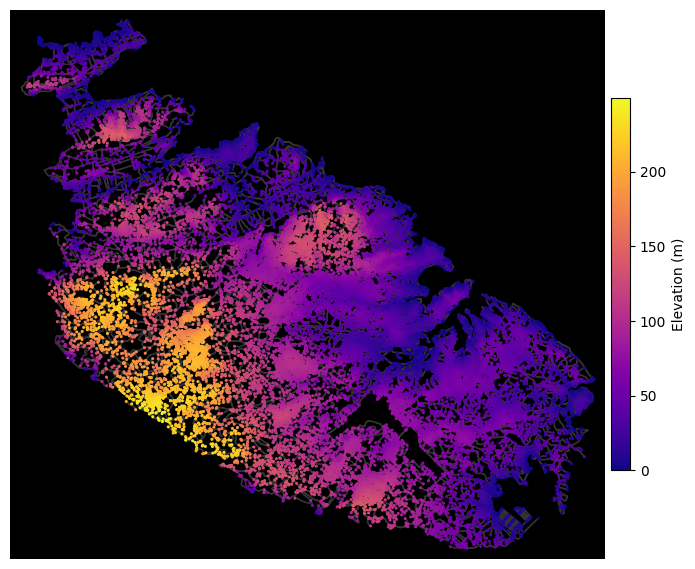

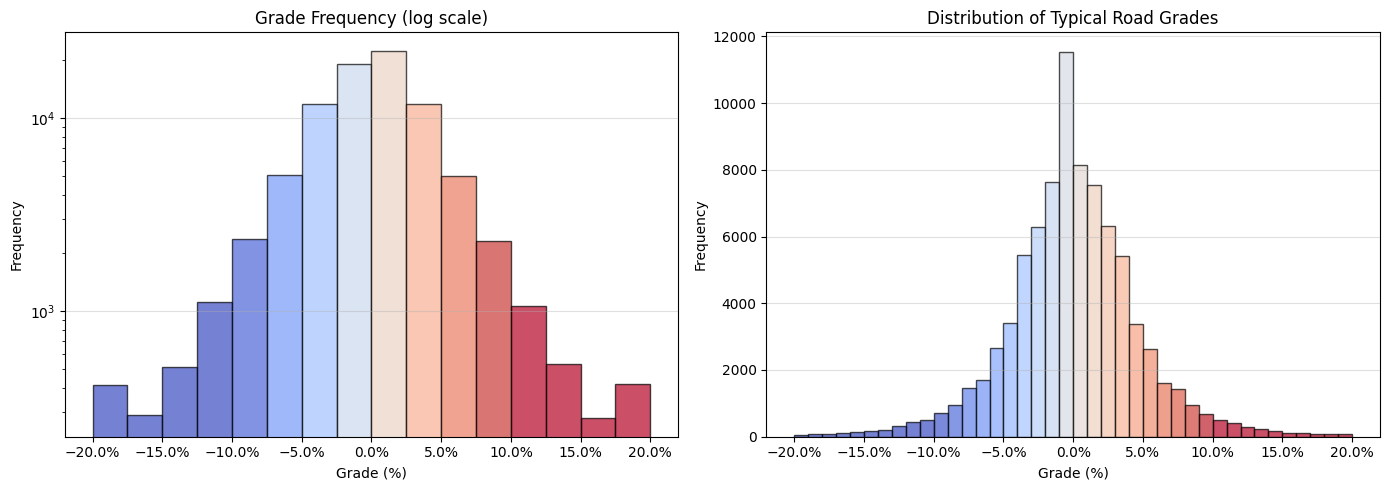

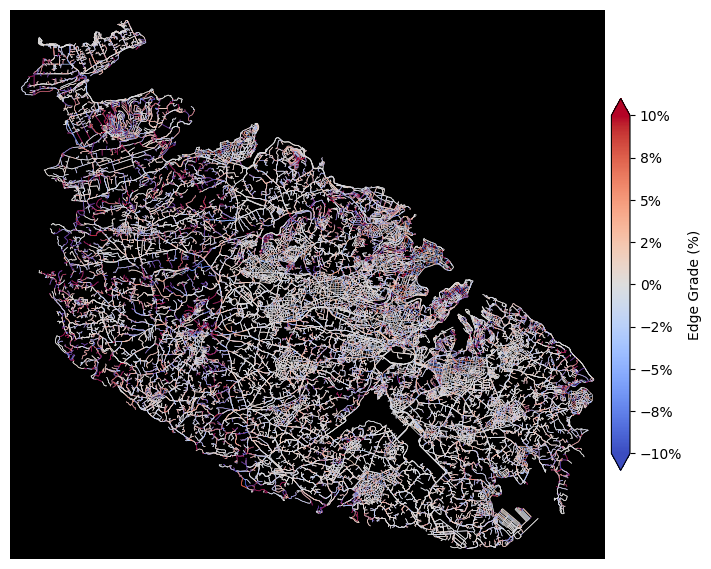

In [7]:
plotting.plot_elevation(G_master)
plotting.plot_grades(G_master)

## Network statistics

In [8]:
"""# what sized area does our network cover in square meters?
bike_nodes_proj = ox.convert.graph_to_gdfs(my_graph.G_master, edges=False) #Get only nodes
graph_area_m = bike_nodes_proj.union_all().convex_hull.area
# show some basic stats about the network
stats = ox.stats.basic_stats(my_graph.G_master, area=graph_area_m, clean_int_tol=15)"""

'# what sized area does our network cover in square meters?\nbike_nodes_proj = ox.convert.graph_to_gdfs(my_graph.G_master, edges=False) #Get only nodes\ngraph_area_m = bike_nodes_proj.union_all().convex_hull.area\n# show some basic stats about the network\nstats = ox.stats.basic_stats(my_graph.G_master, area=graph_area_m, clean_int_tol=15)'

In [9]:
edge_keys = set()
for u,v,data in G_master.edges(data=True):
    edge_keys.update(data.keys())
print(edge_keys)

{'name:en', 'car_lanes', 'grade', 'car_allowed', 'tunnel', 'grade_abs', 'length', 'bike_allowed', 'name', 'bridge', 'risk_factor', 'bicycle', 'oneway', 'width', 'osmid', 'reversed', 'bike_lanes', 'highway', 'geometry', 'region', 'safety', 'cycleway'}


# Generating city level subgraphs

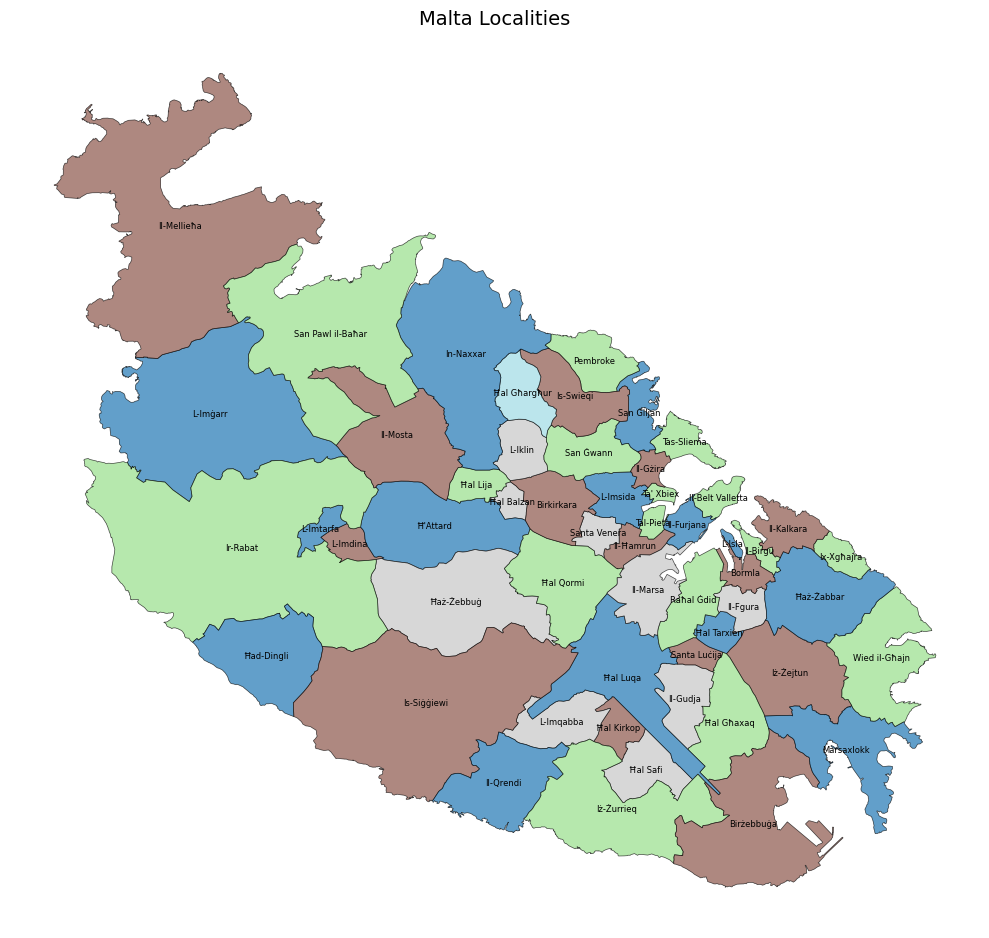

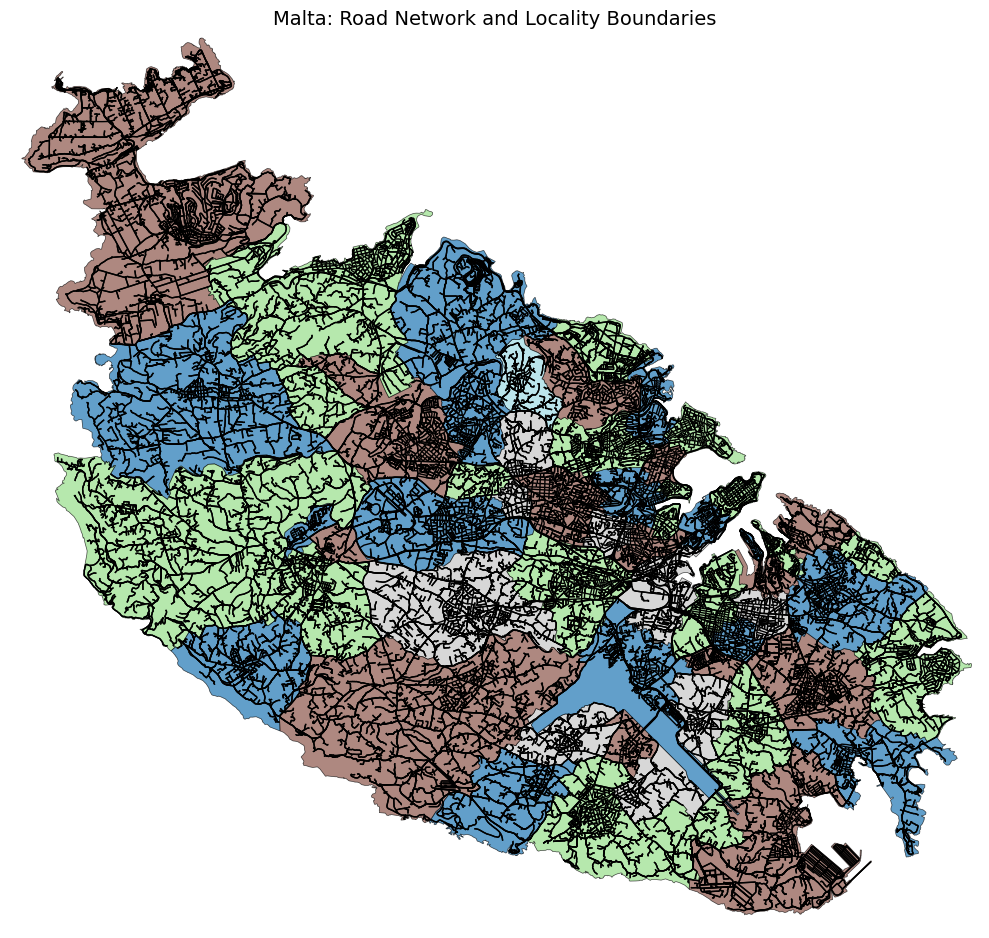

In [10]:
localities = list(gdf_localities_proj["name"])

# Assign distinct colors
gdf_colored = plotting.assign_adjacent_colors(gdf_localities_proj, cmap_name="tab20")

# Plot only polygons
plotting.plot_colored_polygons(gdf_colored, title="Malta Localities")

# Plot polygons + road network overlay
plotting.plot_colored_polygons(
    gdf_colored,
    G=G_master,
    title="Malta: Road Network and Locality Boundaries",
    annotate=False
)

In [11]:
subgraphs = {}
total_nodes = 0
total_edges = 0
for idx, row in gdf_localities_proj.iterrows():
    name = row["name"]
    #TODO make subgraph for drive

    G_sub = graph_manager.make_region_subgraph(G_master, name)
    subgraphs[name] = G_sub
    total_nodes += len(G_sub.nodes)
    total_edges += len(G_sub.edges)
    print(f"✅ Created subgraph for {name}: {len(G_sub.nodes)} nodes, {len(G_sub.edges)} edges")

print(f"total_nodes{total_nodes}, total_edges{total_edges}")

✅ Created subgraph for Il-Birgu: 242 nodes, 538 edges
✅ Created subgraph for Tas-Sliema: 342 nodes, 650 edges
✅ Created subgraph for L-Imġarr: 1171 nodes, 2612 edges
✅ Created subgraph for Il-Mellieħa: 2635 nodes, 6252 edges
✅ Created subgraph for Il-Ħamrun: 383 nodes, 806 edges
✅ Created subgraph for Santa Venera: 267 nodes, 568 edges
✅ Created subgraph for L-Imdina: 135 nodes, 289 edges
✅ Created subgraph for Ħal Balzan: 190 nodes, 402 edges
✅ Created subgraph for Ħ'Attard: 1120 nodes, 2669 edges
✅ Created subgraph for Ħaż-Żebbuġ: 1239 nodes, 2855 edges
✅ Created subgraph for Ħal Safi: 284 nodes, 642 edges
✅ Created subgraph for Ħal Kirkop: 272 nodes, 580 edges
✅ Created subgraph for L-Imqabba: 394 nodes, 925 edges
✅ Created subgraph for Ħal Qormi: 1152 nodes, 2637 edges
✅ Created subgraph for Il-Gudja: 359 nodes, 840 edges
✅ Created subgraph for Santa Luċija: 226 nodes, 548 edges
✅ Created subgraph for Ħal Tarxien: 359 nodes, 780 edges
✅ Created subgraph for Il-Fgura: 339 nodes, 715

# Topological Metrics

Evaluating how good a network is

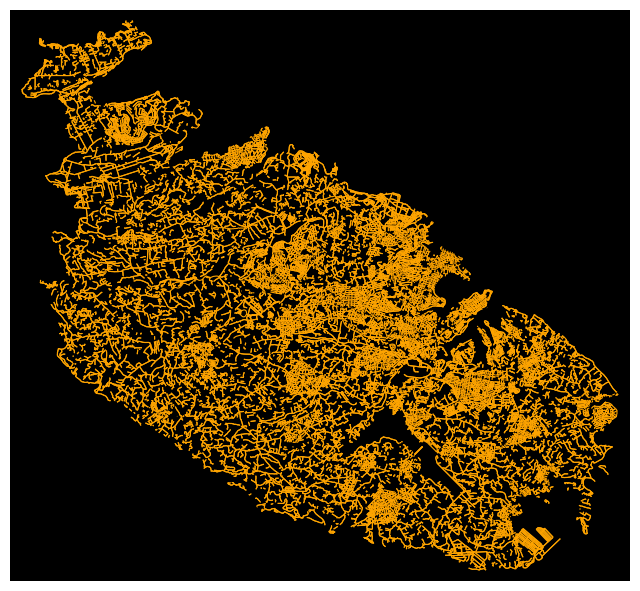

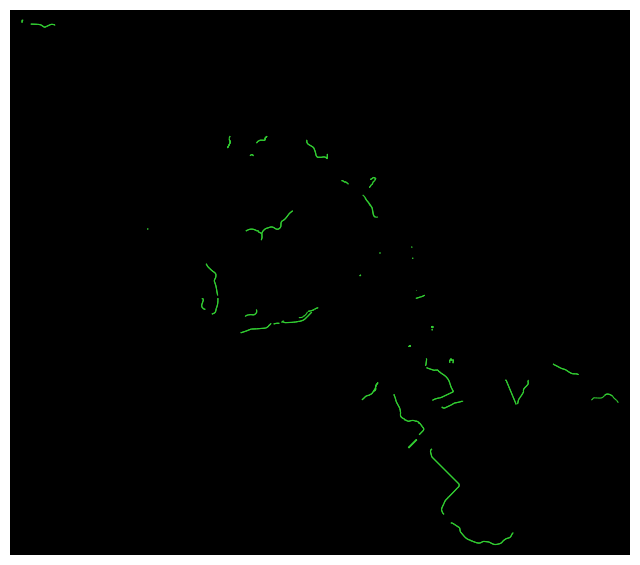

In [12]:
fig, ax = ox.plot_graph(
    graph_manager.make_bikeable_subgraph(G_master),
    node_size=0,
    edge_color="orange",
    edge_linewidth=0.8,
    bgcolor="k"
)

fig, ax = ox.plot_graph(
    graph_manager.make_protected_subgraph(G_master),
    node_size=0,
    edge_color="limegreen",
    edge_linewidth=0.8,
    bgcolor="k"
)

In [13]:
# Connectedness - describing whether the network forms a single, navigable system or remains fragmented into multiple component
def calc_connectedness(G:MultiDiGraph, G_lcc:MultiDiGraph) -> dict:
    num_components = nx.number_strongly_connected_components(G)
    lcc_length = float(sum(d.get("length", 0) for _, _, d in G_lcc.edges(data=True)))

    return {
        "num_components": num_components,
        "lcc_length": lcc_length,
    }


"""def calc_directness(Gb_lcc:MultiDiGraph, G_drive:MultiDiGraph, k = SAMPLE_K, seed=SEED):
    #TODO update when I actually have OD matrix data
    rng = random.Random(seed)

    nodes_b = list(Gb_lcc.nodes())
    if len(nodes_b) < 2:
        raise ValueError("Bike LCC has fewer than 2 nodes.")
    K_eff = min(k, len(nodes_b) * 5)  # keep reasonable number of pairs
    rng.seed(seed)
    ods = []
    while len(ods) < K_eff:
        o = rng.choice(nodes_b)
        d = rng.choice(nodes_b)
        if o != d:
            ods.append((o, d))
            
    pass"""

def calc_centrality(G_lcc:MultiDiGraph, k=SAMPLE_K, seed = SEED) -> dict:
    """Calculate comprehensive centrality metrics for cycling network assessment"""
    #NOTE full centrality is O(n^3), k is instead used to approximate

    num_nodes = len(G_lcc.nodes)
    k_eff = min(k, num_nodes)
    
    # Edge betweenness centrality - connectors for network resilience
    edge_between_cent = nx.edge_betweenness_centrality(G_lcc, weight="length", normalized=True, k=k_eff, seed = seed)
    mean_edge_between_cent = float(np.mean(list(edge_between_cent.values())))

    # betweenness centrality - measures how frequently a link lies on the shortest paths between all node pair
    node_between_cent = nx.betweenness_centrality(G_lcc, weight="length", normalized=True, k=k_eff, seed = seed)
    mean_node_between_cent = float(np.mean(list(node_between_cent.values())))

    #closeness_centrality - how close all other nodes are 
    node_close_cent = nx.closeness_centrality(G_lcc, distance="length")
    mean_node_close_cent = float(np.mean(list(node_close_cent.values())))

    degrees = [d for _, d in G_lcc.degree()]
    mean_degree = float(np.mean(degrees))
        
    return {
        "mean_edge_betweenness": mean_edge_between_cent,
        "mean_node_betweenness": mean_node_between_cent,
        "mean_node_closeness": mean_node_close_cent,
        "mean_degree": mean_degree,
    }


def network_evaluation(G:MultiDiGraph) -> dict:
    G_lcc = ox.truncate.largest_component(G, strongly=True) #NOTE strongly connected true since roads cycle infrastructure is directional

    connectedness = calc_connectedness(G, G_lcc)
    centrality  = calc_centrality(G_lcc)
    results = {**connectedness, **centrality}
    return results

In [14]:
# Directness - measures how efficiently users can travel between two point

# Centrality
network_evaluation(my_graph.make_protected_subgraph(my_graph.G_master))
## Degree - number of connections per node

NameError: name 'my_graph' is not defined

# Optimisation Approaches 

## Heuristic Approaches

Centrality - betweeness and closeness

In [15]:
def heuristic(G_master:MultiDiGraph, G_drive:MultiDiGraph, k=SAMPLE_K, seed=SEED):     
    edges_between_cent = nx.edge_betweenness_centrality(G_drive, weight="length", normalized=True, k=k, seed=seed)
    max_between_cent_edge = max(edges_between_cent, key=edges_between_cent.get)
    print(max_between_cent_edge)
    
    u,v,k = max_between_cent_edge
    #print(f"edge before: {G_master[u][v][k]}")
    graph_manager.reallocate_edge(G_master, max_between_cent_edge)
    #print(f"edge after: {G_master[u][v][k]}" )

def run_locality_task(name, G_sub, heuristic_func, n_iterations):
    """Worker function for a single locality."""
    print(f"🏙️ Starting {name} in process")
    G_working = copy.deepcopy(G_sub)

    for i in range(n_iterations):
        G_drive = graph_manager.make_drive_subgraph(G_working)
        heuristic_func(G_working, G_drive)

    evaluation = network_evaluation(G_working)
    evaluation["locality"] = name
    return evaluation


def run_global_parallel(G_master, subgraphs, heuristic_func, n_iterations=10, max_workers=None):
    """Run heuristic on all subgraphs in parallel."""
    tasks = [(name, G_sub_master, heuristic_func, n_iterations) for name, G_sub_master in subgraphs.items()]
    results = []

    with concurrent.futures.ProcessPoolExecutor(max_workers=max_workers) as executor:
        for result in executor.map(run_locality_task, tasks):
            results.append(result)

    df_results = pd.DataFrame(results)
    df_results.index.name = "locality"
    return df_results

In [17]:
df_results = run_global_parallel(
    G_master=G_master,
    subgraphs=subgraphs,
    heuristic_func=heuristic,
    n_iterations=5,
    max_workers=None
)
print(df_results.head())

AttributeError: Can't pickle local object 'show_multidiedges.<locals>.<lambda>'

In [ ]:
%snakeviz -t results = run_simulation(my_graph)

#plotting.plot_evaluation(df_results)


TypeError: heuristic() missing 1 required positional argument: 'G_master'